# Frequency-Domain Heterodyning

Heterodyning removes a reference chirp phase from every waveform:

$$h_\text{het}(f) = h(f) \times e^{-i\,\varphi_\text{ref}(f)}$$

where $\varphi_\text{ref}(f) = \angle\, h_\text{ref}(f)$ is the phase of a
fixed reference waveform.  The residual phase

$$\delta\Psi(f) = \Psi(f) - \varphi_\text{ref}(f)$$

varies more slowly in $f$ than the original $\Psi(f)$, enabling coarser
frequency-bin spacing.

**Key difference from DINGO**: DINGO estimates the chirp mass per-event and
uses a matched reference.  For a *search* pipeline we cannot estimate the
chirp mass first — that would already be the search.  Instead we use a
**single fixed reference** drawn from the **median of the prior**.  This
notebook explores how well that works for the O3b BBH prior (7–50 M☉).

Building blocks:
- `sage.dsp.heterodyning.apply_heterodyne` — mirrors DINGO `add_phase`
- `sage.dsp.heterodyning.compute_reference_phase` — φ_ref from PyCBC
- `sage.dsp.heterodyning.make_median_reference_binary` — median prior binary
- `sage.dsp.heterodyning.residual_chirp_time` — τ_het from phase gradient

## 1. Imports and segment parameters

In [1]:
import sys, os, warnings, math
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')
import lalsimulation as lalsim
import pycbc.waveform

sys.path.insert(0, os.path.abspath('../runs/o3b'))
from config import set_configs
set_configs()

from sage.dsp.heterodyning import (
    apply_heterodyne,
    compute_reference_phase,
    make_median_reference_binary,
    residual_chirp_time,
)

plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})
print('Imports OK')

Registered cfg and data_cfg!
Imports OK


In [2]:
# ── Segment geometry ────────────────────────────────────────────────────────
SAMPLE_RATE = 2048.0   # Hz
DURATION    = 12.0     # s
F_MIN       = 20.0     # Hz
F_MAX       = SAMPLE_RATE / 2.0   # 1024 Hz
DELTA_F     = 1.0 / DURATION
N_TIME      = int(SAMPLE_RATE * DURATION)
N_FREQ      = N_TIME // 2 + 1

# ── Prior range ─────────────────────────────────────────────────────────────
M_MIN, M_MAX = 7.0, 50.0
SPIN_MAX     = 0.99

MSUN_KG = 1.989e30

print(f'Segment  : {DURATION} s  @  {SAMPLE_RATE:.0f} Hz   Δf = {DELTA_F:.4f} Hz')
print(f'rFFT bins: {N_FREQ}   (N_time = {N_TIME})')
print(f'Prior    : m1, m2 ∈ [{M_MIN}, {M_MAX}] M☉   |s| ≤ {SPIN_MAX}')

Segment  : 12.0 s  @  2048 Hz   Δf = 0.0833 Hz
rFFT bins: 12289   (N_time = 24576)
Prior    : m1, m2 ∈ [7.0, 50.0] M☉   |s| ≤ 0.99


## 2. Prior chirp-time distribution

Sample the prior and compute $\tau(f_\min)$ to understand the spread we need
the heterodyne to cover.

In [3]:
N_PRIOR = 2000
rng = np.random.default_rng(42)

m1_prior = rng.uniform(M_MIN, M_MAX, N_PRIOR)
m2_prior = np.array([rng.uniform(M_MIN, m) for m in m1_prior])
s1z_prior = rng.uniform(-SPIN_MAX, SPIN_MAX, N_PRIOR)
s2z_prior = rng.uniform(-SPIN_MAX, SPIN_MAX, N_PRIOR)

tau_prior = np.array([
    lalsim.SimIMRPhenomDChirpTime(
        m1 * MSUN_KG, m2 * MSUN_KG, float(s1z), float(s2z), F_MIN
    )
    for m1, m2, s1z, s2z in zip(m1_prior, m2_prior, s1z_prior, s2z_prior)
])

# Mchirp for colour-coding
eta_prior  = m1_prior * m2_prior / (m1_prior + m2_prior)**2
mchirp_prior = eta_prior**0.6 * (m1_prior + m2_prior)

print(f'τ(f_min={F_MIN} Hz) over prior:')
for name, val in [
    ('min   ', tau_prior.min()),
    ('5th   ', np.percentile(tau_prior, 5)),
    ('median', np.median(tau_prior)),
    ('95th  ', np.percentile(tau_prior, 95)),
    ('max   ', tau_prior.max()),
]:
    print(f'  {name}: {val:.3f} s')

τ(f_min=20.0 Hz) over prior:
  min   : 0.245 s
  5th   : 0.468 s
  median: 1.694 s
  95th  : 7.680 s
  max   : 11.276 s


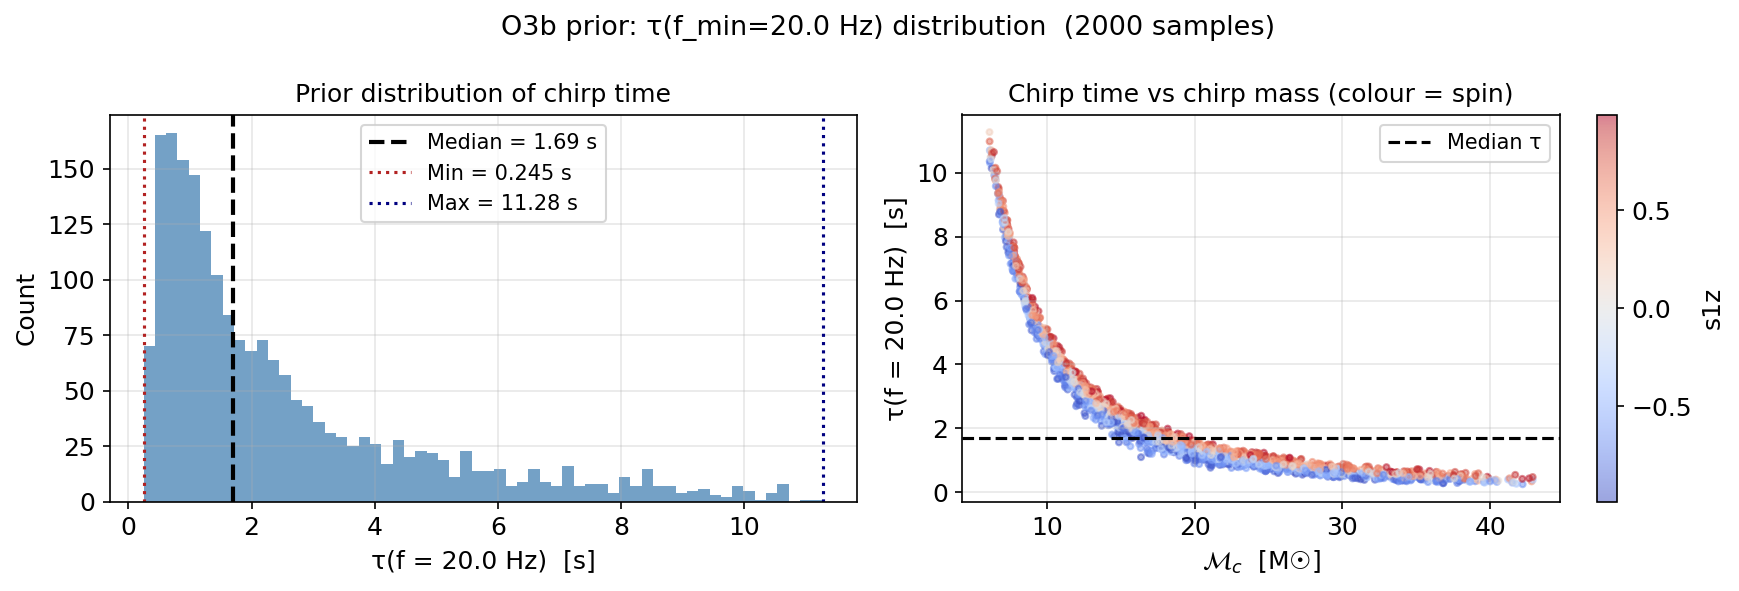

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

ax = axes[0]
ax.hist(tau_prior, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
ax.axvline(np.median(tau_prior), color='k', lw=2, ls='--', label=f'Median = {np.median(tau_prior):.2f} s')
ax.axvline(tau_prior.min(), color='firebrick', lw=1.5, ls=':', label=f'Min = {tau_prior.min():.3f} s')
ax.axvline(tau_prior.max(), color='navy', lw=1.5, ls=':', label=f'Max = {tau_prior.max():.2f} s')
ax.set_xlabel(f'τ(f = {F_MIN} Hz)  [s]', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Prior distribution of chirp time', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
sc = ax.scatter(mchirp_prior, tau_prior, c=s1z_prior, cmap='coolwarm',
                s=8, alpha=0.5, vmin=-SPIN_MAX, vmax=SPIN_MAX)
plt.colorbar(sc, ax=ax, label='s1z')
ax.axhline(np.median(tau_prior), color='k', lw=1.5, ls='--', label='Median τ')
ax.set_xlabel(r'$\mathcal{M}_c$  [M☉]', fontsize=12)
ax.set_ylabel(f'τ(f = {F_MIN} Hz)  [s]', fontsize=12)
ax.set_title('Chirp time vs chirp mass (colour = spin)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(f'O3b prior: τ(f_min={F_MIN} Hz) distribution  ({N_PRIOR} samples)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Reference binary: median prior

`make_median_reference_binary` draws 2000 prior samples, takes the median
$\tau(f_\min)$, then binary-searches for the equal-mass, zero-spin binary
that matches that median.

In [5]:
m_ref, _, _, _ = make_median_reference_binary(
    M_MIN, M_MAX, SPIN_MAX,
    f_eval=F_MIN,
    n_samples=N_PRIOR,
    seed=42,
)

tau_ref = lalsim.SimIMRPhenomDChirpTime(
    m_ref * MSUN_KG, m_ref * MSUN_KG, 0.0, 0.0, F_MIN
)
eta_ref    = 0.25   # equal mass → η = 1/4
mchirp_ref = eta_ref**0.6 * (2 * m_ref)

print(f'Reference binary : {m_ref:.2f} + {m_ref:.2f} M☉  (s1z = s2z = 0)')
print(f'Chirp mass       : {mchirp_ref:.2f} M☉')
print(f'τ(f_min={F_MIN} Hz) : {tau_ref:.3f} s  (prior median: {np.median(tau_prior):.3f} s)')

Reference binary : 20.61 + 20.61 M☉  (s1z = s2z = 0)
Chirp mass       : 17.94 M☉
τ(f_min=20.0 Hz) : 1.694 s  (prior median: 1.694 s)


## 4. Reference phase and test waveforms

In [6]:
# ── Reference phase ──────────────────────────────────────────────────────────
phi_ref = compute_reference_phase(
    m_ref, m_ref, 0.0, 0.0,
    sample_rate=SAMPLE_RATE,
    duration=DURATION,
    f_min=F_MIN,
    f_max=F_MAX,
    approximant='IMRPhenomD',
    coa_phase=0.0,
)
freqs = np.arange(N_FREQ) * DELTA_F

print(f'Reference phase: shape {phi_ref.shape}  '
      f'non-zero bins: {(phi_ref != 0).sum()}')

# ── Test binaries spanning the prior ────────────────────────────────────────
#   lightest (worst case) / reference / heaviest — all face-on, t_c = 0
WF_COMMON = dict(
    sample_rate=SAMPLE_RATE, duration=DURATION,
    f_min=F_MIN, f_max=F_MAX,
    approximant='IMRPhenomD', coa_phase=0.0,
)

test_cases = {
    'Lightest (7+7, s=0.99)':  dict(m1=7.0,    m2=7.0,    s1z=0.99, s2z=0.99, color='navy'),
    'Light    (7+7, s=0.00)':  dict(m1=7.0,    m2=7.0,    s1z=0.00, s2z=0.00, color='steelblue'),
    f'Reference ({m_ref:.1f}+{m_ref:.1f}, s=0)':  dict(m1=m_ref,  m2=m_ref,  s1z=0.00, s2z=0.00, color='black'),
    'Heavy    (50+50, s=0.00)':dict(m1=50.0,   m2=50.0,   s1z=0.00, s2z=0.00, color='orangered'),
    'Heaviest (50+50, s=0.99)':dict(m1=50.0,   m2=50.0,   s1z=0.99, s2z=0.99, color='firebrick'),
}

def gen_fd(p):
    hp, _ = pycbc.waveform.get_fd_waveform(
        approximant='IMRPhenomD',
        mass1=p['m1'], mass2=p['m2'],
        spin1z=p['s1z'], spin2z=p['s2z'],
        delta_f=DELTA_F, f_lower=F_MIN, f_final=F_MAX,
        distance=100.0, coa_phase=0.0,
    )
    h = np.array(hp, dtype=np.complex128)
    if len(h) < N_FREQ:
        h = np.concatenate([h, np.zeros(N_FREQ - len(h), dtype=np.complex128)])
    return h[:N_FREQ]

for label, p in test_cases.items():
    h = gen_fd(p)
    p['h'] = h
    p['h_het'] = apply_heterodyne(h, phi_ref)
    tau_f = lalsim.SimIMRPhenomDChirpTime(
        p['m1'] * MSUN_KG, p['m2'] * MSUN_KG, p['s1z'], p['s2z'], F_MIN
    )
    p['tau_fmin'] = tau_f
    print(f'  {label:<36} |h|_max={np.abs(h).max():.2e}  τ(f_min)={tau_f:.3f} s')

Reference phase: shape (12289,)  non-zero bins: 11578
  Lightest (7+7, s=0.99)               |h|_max=1.06e-22  τ(f_min)=11.580 s
  Light    (7+7, s=0.00)               |h|_max=1.04e-22  τ(f_min)=10.946 s
  Reference (20.6+20.6, s=0)           |h|_max=2.48e-22  τ(f_min)=1.694 s
  Heavy    (50+50, s=0.00)             |h|_max=4.79e-22  τ(f_min)=0.334 s
  Heaviest (50+50, s=0.99)             |h|_max=5.39e-22  τ(f_min)=0.552 s


/tmp/ipykernel_2035275/1033821140.py:40: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  h = np.array(hp, dtype=np.complex128)


## 5. Residual phase and chirp-time after heterodyning

The residual chirp time
$$
\tau_\text{het}(f) = \frac{|\delta\Psi(f_{k+1}) - \delta\Psi(f_k)|}{2\pi\Delta f}
= \frac{|\angle[h_\text{het}(f_{k+1})\,h_\text{het}^*(f_k)]|\cdot T}{2\pi}
$$
measures how slowly the heterodyned signal oscillates.  If it is much smaller
than the original $\tau(f)$, heterodyning enables coarser frequency bins.

In [7]:
# Compute τ_het from phase gradient of h_het
for label, p in test_cases.items():
    tau_het = residual_chirp_time(p['h_het'], DURATION)
    # Also compute the original τ directly from IMRPhenomDChirpTime
    freqs_mid = freqs[:-1] + 0.5 * DELTA_F
    tau_orig = np.array([
        lalsim.SimIMRPhenomDChirpTime(
            p['m1'] * MSUN_KG, p['m2'] * MSUN_KG,
            p['s1z'], p['s2z'], f
        ) if f >= F_MIN else float('nan')
        for f in freqs_mid
    ])
    p['tau_het']  = tau_het
    p['tau_orig'] = tau_orig
    p['freqs_mid'] = freqs_mid

# Print summary: max τ_het in [F_MIN, F_MAX] vs original τ(F_MIN)
print(f'  {"Case":<36}  {"τ(f_min) [s]":>14}  {"max τ_het [s]":>14}  {"Reduction":>10}')
print('  ' + '-' * 80)
for label, p in test_cases.items():
    mask = p['freqs_mid'] >= F_MIN
    tau_het_max = p['tau_het'][mask].max() if mask.any() else float('nan')
    reduction = p['tau_fmin'] / tau_het_max if tau_het_max > 0 else float('nan')
    print(f'  {label:<36}  {p["tau_fmin"]:>14.3f}  {tau_het_max:>14.3f}  {reduction:>9.2f}×')

  Case                                    τ(f_min) [s]   max τ_het [s]   Reduction
  --------------------------------------------------------------------------------
  Lightest (7+7, s=0.99)                        11.580           5.977       1.94×
  Light    (7+7, s=0.00)                        10.946           5.988       1.83×
  Reference (20.6+20.6, s=0)                     1.694           0.000  1588286975330164.50×
  Heavy    (50+50, s=0.00)                       0.334           1.357       0.25×
  Heaviest (50+50, s=0.99)                       0.552           1.165       0.47×


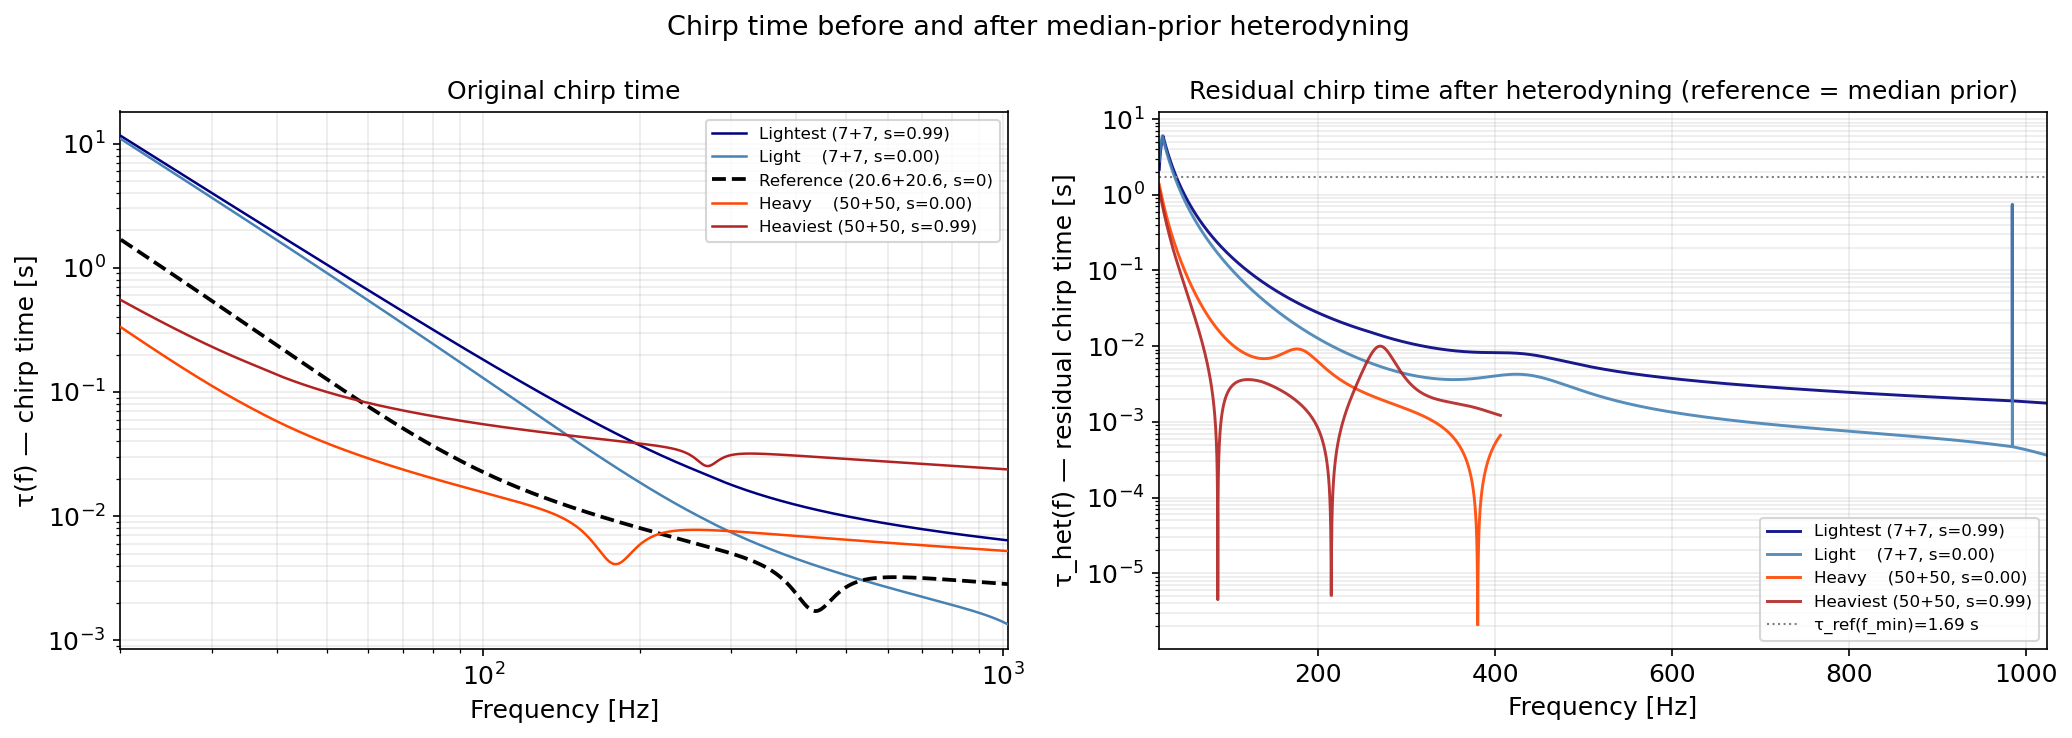

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# ── Left: τ(f) before heterodyning ──────────────────────────────────────────
ax = axes[0]
for label, p in test_cases.items():
    mask = p['freqs_mid'] >= F_MIN
    valid = mask & (p['tau_orig'] > 0) & ~np.isnan(p['tau_orig'])
    ax.loglog(p['freqs_mid'][valid], p['tau_orig'][valid],
              color=p['color'], lw=1.8 if 'Reference' in label else 1.2,
              ls='-' if 'Reference' not in label else '--',
              label=label, zorder=4)

ax.set_xlabel('Frequency [Hz]', fontsize=12)
ax.set_ylabel('τ(f) — chirp time [s]', fontsize=12)
ax.set_title('Original chirp time', fontsize=12)
ax.set_xlim(F_MIN, F_MAX)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.25)

# ── Right: τ_het(f) after heterodyning ──────────────────────────────────────
ax = axes[1]
for label, p in test_cases.items():
    if 'Reference' in label:
        continue   # reference heterodynes to zero by construction
    mask = p['freqs_mid'] >= F_MIN
    tau_h = np.where(p['tau_het'] > 1e-6, p['tau_het'], np.nan)
    ax.semilogy(p['freqs_mid'][mask], tau_h[mask],
                color=p['color'], lw=1.4, label=label, alpha=0.9)

# Reference line at τ_ref(F_MIN)
ax.axhline(tau_ref, color='gray', lw=1.0, ls=':', label=f'τ_ref(f_min)={tau_ref:.2f} s')

ax.set_xlabel('Frequency [Hz]', fontsize=12)
ax.set_ylabel('τ_het(f) — residual chirp time [s]', fontsize=12)
ax.set_title('Residual chirp time after heterodyning (reference = median prior)', fontsize=12)
ax.set_xlim(F_MIN, F_MAX)
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.25)

plt.suptitle('Chirp time before and after median-prior heterodyning', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Sideband structure

After heterodyning, $h_\text{het}(f)$ carries a **residual phase** $\delta\Psi(f)$
relative to the reference.

* **Positive sideband** — signals *slower* than the reference ($\tau > \tau_\text{ref}$,
  lighter / lower spin): $\delta\Psi > 0$, phase increases with $f$.
* **Negative sideband** — signals *faster* than the reference ($\tau < \tau_\text{ref}$,
  heavier / higher spin): $\delta\Psi < 0$, phase decreases with $f$.

For the reference binary itself $\delta\Psi = 0$ everywhere — a flat (DC)
residual.

The breadth of both sidebands relative to the reference tells us how much
we gain from heterodyning vs. the naive multibanding approach.

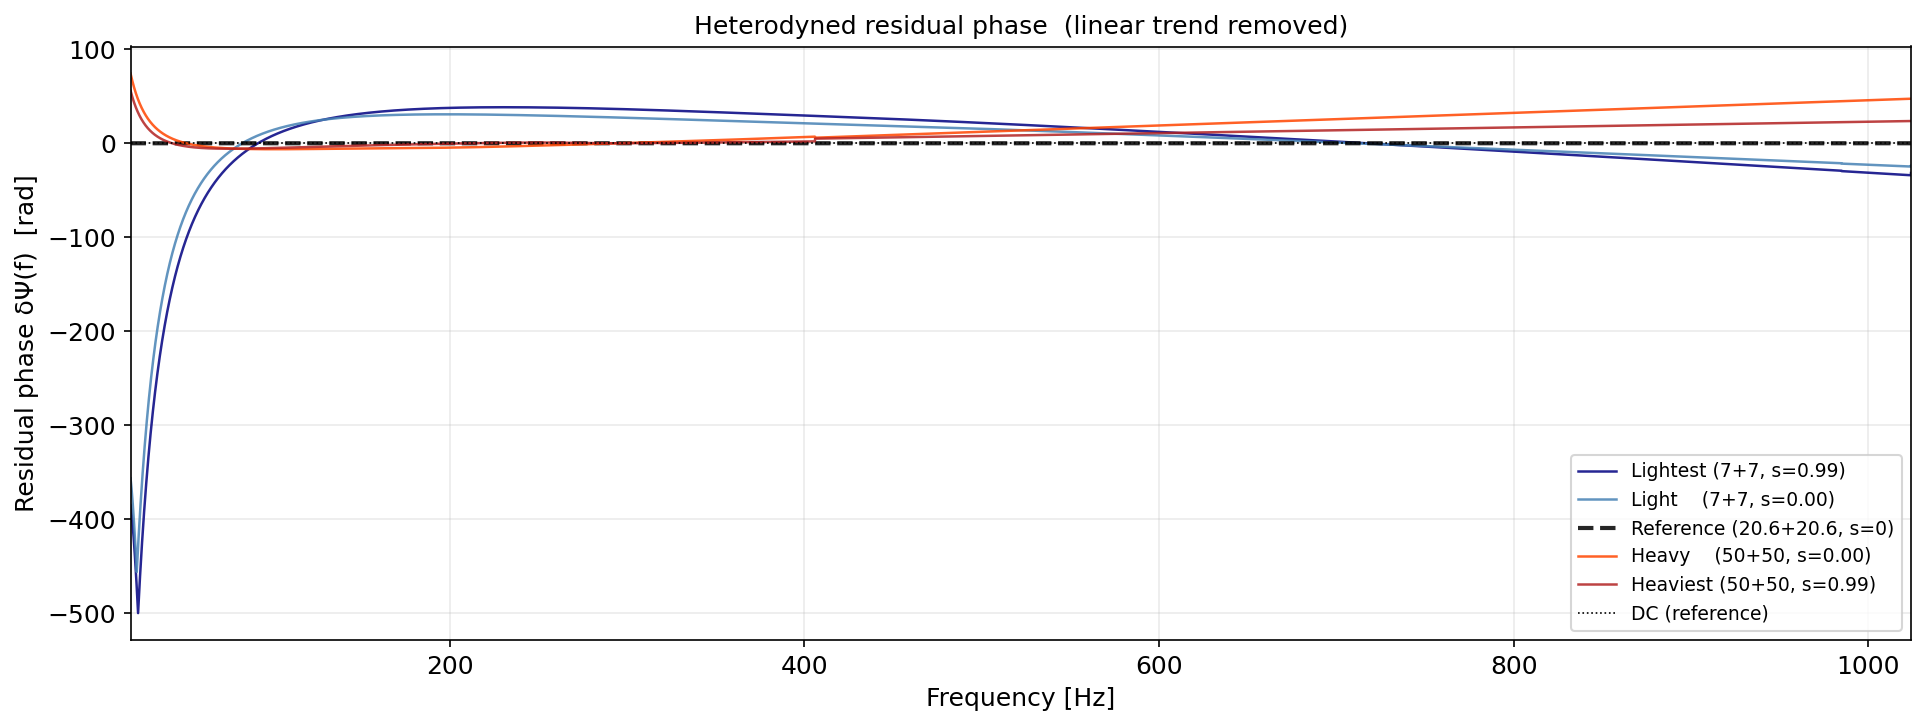

Signals lighter than reference → positive δΨ (positive sideband)
Signals heavier than reference → negative δΨ (negative sideband)
Reference itself              → δΨ ≈ 0 (DC, by construction)


In [9]:
# ── Compute residual (unwrapped) phase δΨ(f) for each test case ─────────────
k_min = int(math.ceil(F_MIN * DURATION))
k_max = int(math.floor(F_MAX * DURATION))

for label, p in test_cases.items():
    h_het = p['h_het'][k_min:k_max + 1]
    nz = np.abs(h_het) > 0
    delta_psi = np.full(len(h_het), np.nan)
    if nz.any():
        raw_phase = np.angle(h_het)
        unwrapped = np.unwrap(raw_phase)
        # Remove linear trend (carrier from t_c): fit and subtract
        f_bins = np.arange(k_min, k_max + 1) * DELTA_F
        # Only fit over non-zero bins
        if nz.sum() >= 2:
            c = np.polyfit(f_bins[nz], unwrapped[nz], 1)
            trend = np.polyval(c, f_bins)
            delta_psi = unwrapped - trend
    p['delta_psi'] = delta_psi
    p['f_band'] = np.arange(k_min, k_max + 1) * DELTA_F

# ── Plot δΨ(f) for all test cases ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5), dpi=150)

for label, p in test_cases.items():
    nz = ~np.isnan(p['delta_psi'])
    if nz.any():
        lw = 2.0 if 'Reference' in label else 1.2
        ls = '--' if 'Reference' in label else '-'
        ax.plot(p['f_band'][nz], p['delta_psi'][nz],
                color=p['color'], lw=lw, ls=ls, label=label, alpha=0.85)

ax.axhline(0, color='k', lw=0.8, ls=':', label='DC (reference)')
ax.set_xlabel('Frequency [Hz]', fontsize=12)
ax.set_ylabel('Residual phase δΨ(f)  [rad]', fontsize=12)
ax.set_title('Heterodyned residual phase  (linear trend removed)', fontsize=12)
ax.set_xlim(F_MIN, F_MAX)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print('Signals lighter than reference → positive δΨ (positive sideband)')
print('Signals heavier than reference → negative δΨ (negative sideband)')
print('Reference itself              → δΨ ≈ 0 (DC, by construction)')

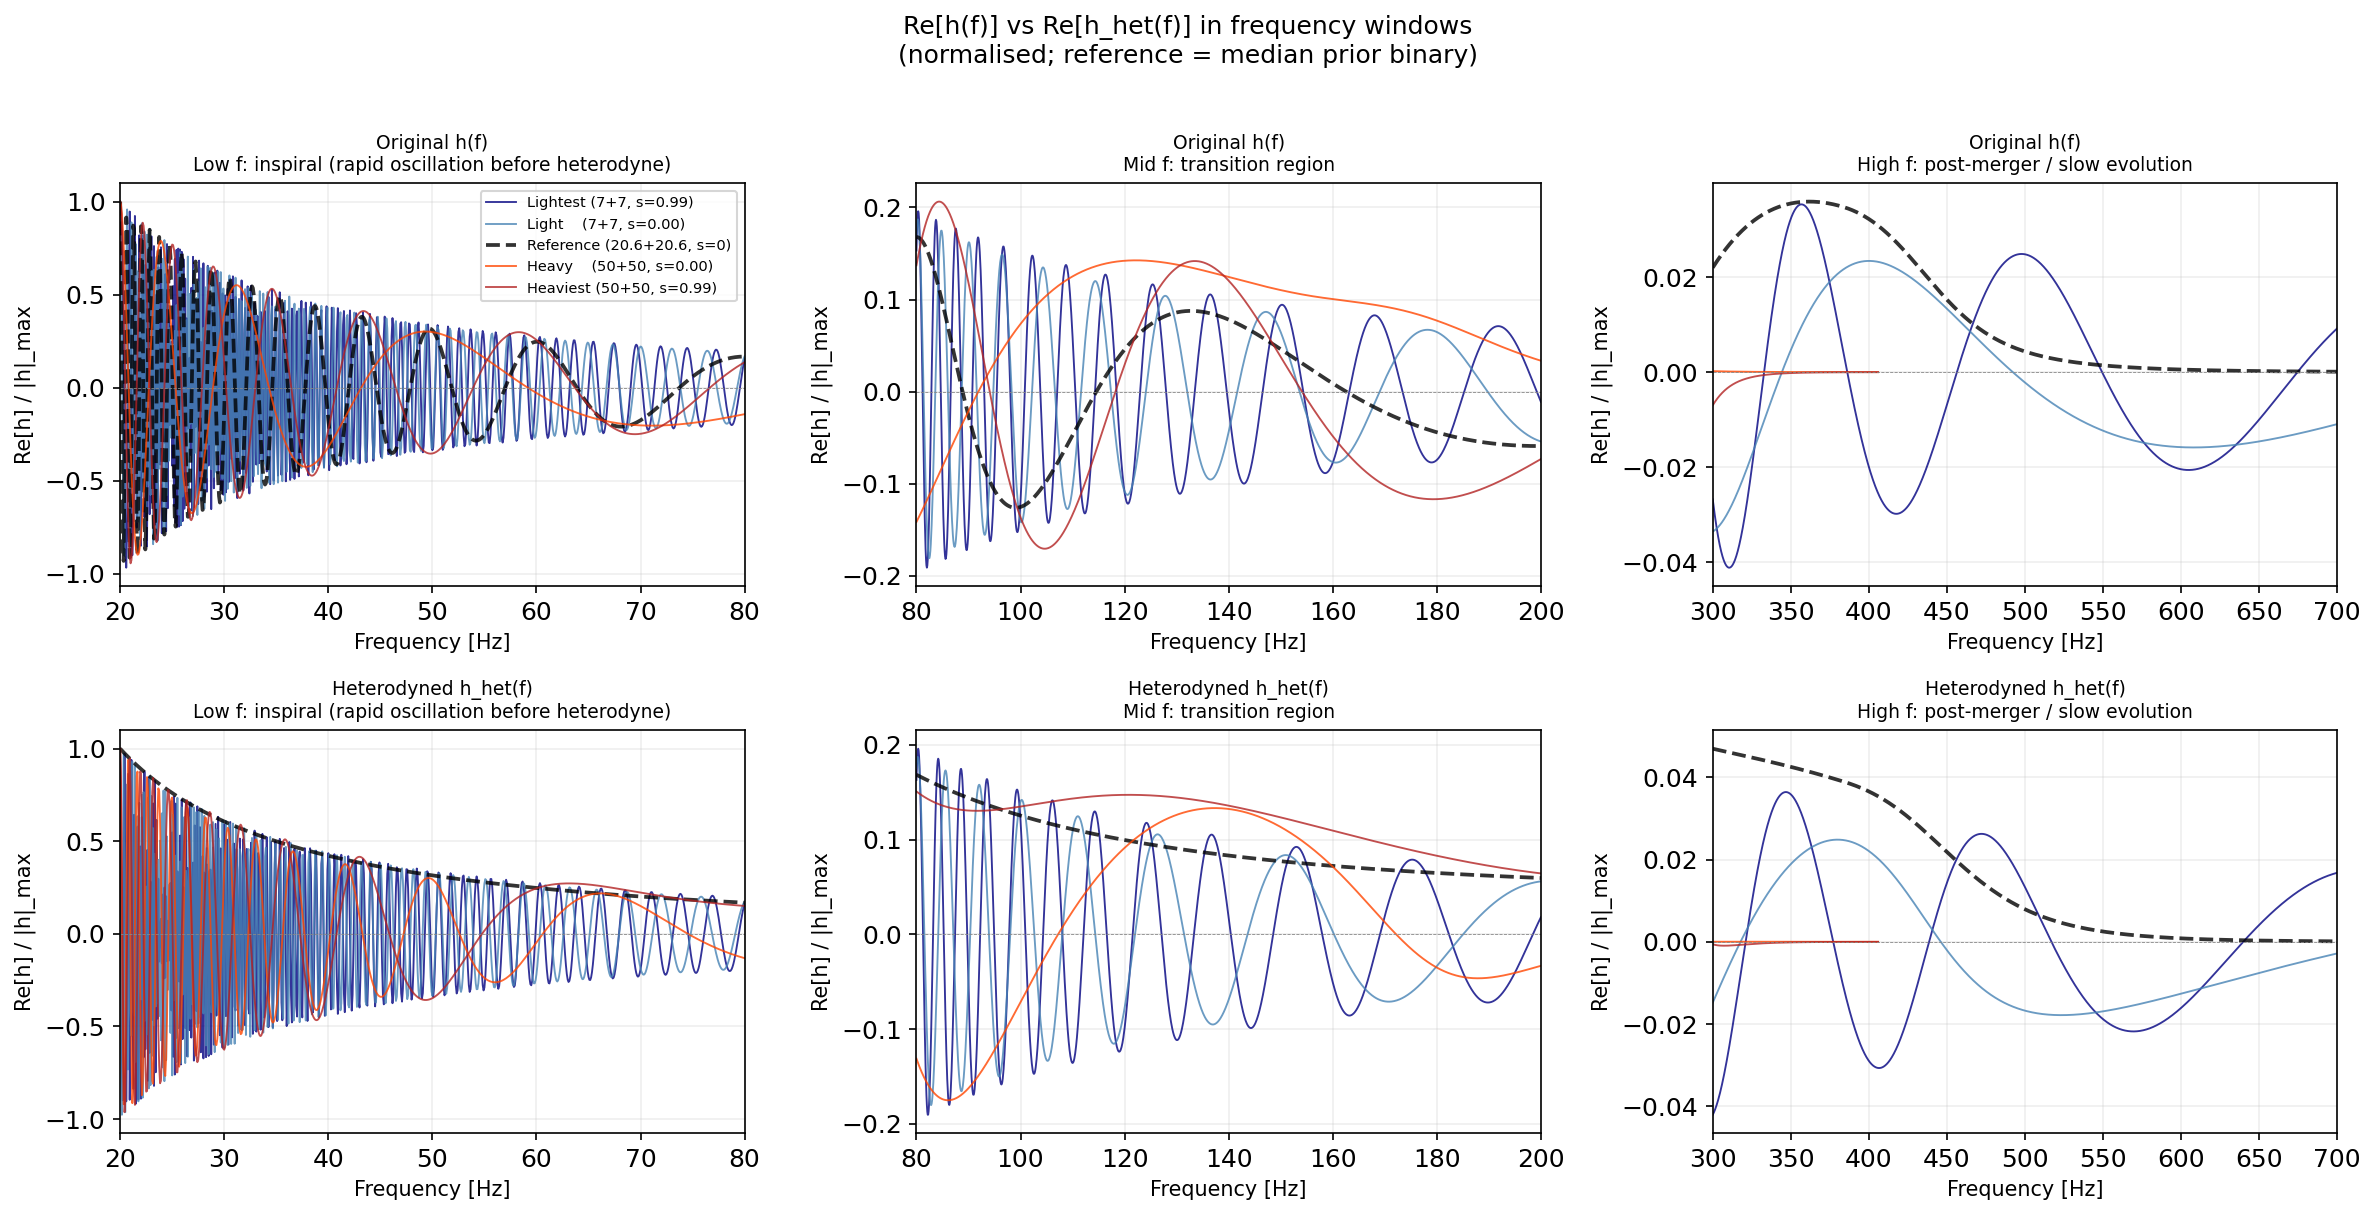

In [10]:
# ── Re[h_het(f)] oscillations in a representative frequency window ───────────
#
# Choose a frequency window where the original signal oscillates rapidly but
# heterodyning should slow things down.

WINDOWS = [
    (20,  80,   'Low f: inspiral (rapid oscillation before heterodyne)'),
    (80,  200,  'Mid f: transition region'),
    (300, 700,  'High f: post-merger / slow evolution'),
]

fig, axes = plt.subplots(2, len(WINDOWS), figsize=(16, 8), dpi=150)

for col, (f_lo, f_hi, title) in enumerate(WINDOWS):
    k1 = int(f_lo * DURATION)
    k2 = int(f_hi * DURATION) + 1
    k2 = min(k2, N_FREQ)
    f_zoom = freqs[k1:k2]

    for row, (h_key, row_title) in enumerate([('h', 'Original h(f)'), ('h_het', 'Heterodyned h_het(f)')]):
        ax = axes[row, col]
        for label, p in test_cases.items():
            hv = p[h_key][k1:k2]
            nz = np.abs(hv) > 0
            if nz.any():
                lw = 1.8 if 'Reference' in label else 0.9
                ls = '--' if 'Reference' in label else '-'
                ax.plot(f_zoom[nz], hv[nz].real / np.abs(p[h_key]).max(),
                        color=p['color'], lw=lw, ls=ls, alpha=0.8,
                        label=label if col == 0 and row == 0 else None)

        ax.axhline(0, color='#888', lw=0.4, ls='--')
        ax.set_xlabel('Frequency [Hz]', fontsize=10)
        ax.set_ylabel('Re[h] / |h|_max', fontsize=10)
        ax.set_title(f'{row_title}\n{title}', fontsize=9)
        ax.set_xlim(f_lo, f_hi)
        ax.grid(True, alpha=0.2)
        if col == 0 and row == 0:
            ax.legend(fontsize=7, loc='upper right')

plt.suptitle(
    'Re[h(f)] vs Re[h_het(f)] in frequency windows\n'
    '(normalised; reference = median prior binary)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## 7. Residual bandwidth: how much does heterodyning help for a broad prior?

For the residual to be sampled with stride $s$, we need $\tau_\text{het} \leq T/(32s)$.
We compute the **worst-case residual chirp time** over the prior at each
frequency by evaluating on a grid of test binaries and taking the maximum.

In [11]:
# Worst-case τ_het across the prior: compare to worst-case τ without heterodyne
#
# We sample 400 binaries and compute τ_het(f) from SimIMRPhenomDChirpTime:
#   τ_het(f) ≈ |τ(f; m1,m2,s) - τ_ref(f)|
# (exact only in the SPA approximation but captures the main effect)

N_SCAN = 400
rng2 = np.random.default_rng(123)
m1_s = rng2.uniform(M_MIN, M_MAX, N_SCAN)
m2_s = np.array([rng2.uniform(M_MIN, m) for m in m1_s])
s1z_s = rng2.uniform(-SPIN_MAX, SPIN_MAX, N_SCAN)
s2z_s = rng2.uniform(-SPIN_MAX, SPIN_MAX, N_SCAN)

f_grid = np.geomspace(F_MIN, F_MAX, 300)

# Reference τ curve
tau_ref_grid = np.array([
    lalsim.SimIMRPhenomDChirpTime(
        m_ref * MSUN_KG, m_ref * MSUN_KG, 0.0, 0.0, f
    ) for f in f_grid
])

# Max and min τ(f) and max |τ(f) - τ_ref(f)| over the scan
tau_max_grid   = np.zeros(len(f_grid))
tau_min_grid   = np.full(len(f_grid), np.inf)
tau_het_max_grid = np.zeros(len(f_grid))

print('Scanning prior...', end=' ')
for m1, m2, s1z, s2z in zip(m1_s, m2_s, s1z_s, s2z_s):
    tau_row = np.array([
        lalsim.SimIMRPhenomDChirpTime(
            m1 * MSUN_KG, m2 * MSUN_KG, float(s1z), float(s2z), f
        ) for f in f_grid
    ])
    tau_max_grid   = np.maximum(tau_max_grid, tau_row)
    tau_min_grid   = np.minimum(tau_min_grid, tau_row)
    tau_het_max_grid = np.maximum(tau_het_max_grid, np.abs(tau_row - tau_ref_grid))
print('done.')

print(f'\n  Worst-case τ(f_min)         (no heterodyne): {tau_max_grid[0]:.3f} s')
print(f'  Worst-case τ_het(f_min) (median heterodyne): {tau_het_max_grid[0]:.3f} s')
print(f'  Reduction at f_min: {tau_max_grid[0] / tau_het_max_grid[0]:.2f}×')

Scanning prior... done.

  Worst-case τ(f_min)         (no heterodyne): 10.635 s
  Worst-case τ_het(f_min) (median heterodyne): 8.941 s
  Reduction at f_min: 1.19×


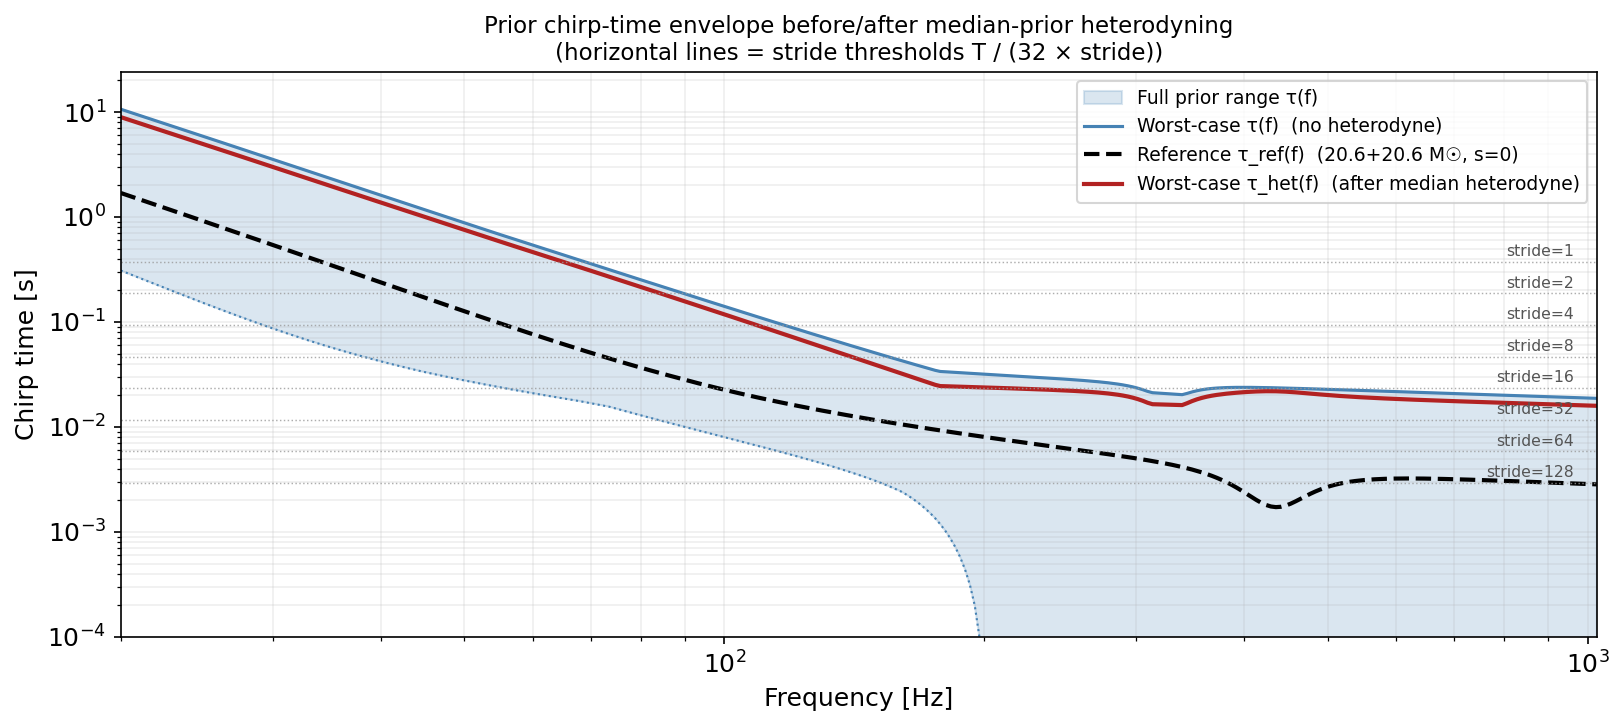

In [12]:
fig, ax = plt.subplots(figsize=(11, 5), dpi=150)

# Shaded band: full prior spread
ax.fill_between(f_grid, tau_min_grid, tau_max_grid,
                color='steelblue', alpha=0.20, label='Full prior range τ(f)')
ax.loglog(f_grid, tau_max_grid, color='steelblue', lw=1.5, ls='-',
          label='Worst-case τ(f)  (no heterodyne)')
ax.loglog(f_grid, tau_min_grid, color='steelblue', lw=1.0, ls=':')
ax.loglog(f_grid, tau_ref_grid, color='black', lw=2.0, ls='--',
          label=f'Reference τ_ref(f)  ({m_ref:.1f}+{m_ref:.1f} M☉, s=0)')
ax.loglog(f_grid, tau_het_max_grid, color='firebrick', lw=2.0, ls='-',
          label='Worst-case τ_het(f)  (after median heterodyne)')

# Stride thresholds T/(32 s)
for s in [1, 2, 4, 8, 16, 32, 64, 128]:
    thresh = DURATION / (32 * s)
    ax.axhline(thresh, color='#999', lw=0.7, ls=':', alpha=0.8)
    ax.text(F_MAX * 0.94, thresh * 1.06, f'stride={s}',
            ha='right', va='bottom', fontsize=7.5, color='#555')

ax.set_xlabel('Frequency [Hz]', fontsize=12)
ax.set_ylabel('Chirp time [s]', fontsize=12)
ax.set_title(
    'Prior chirp-time envelope before/after median-prior heterodyning\n'
    '(horizontal lines = stride thresholds T / (32 × stride))',
    fontsize=11
)
ax.set_xlim(F_MIN, F_MAX)
ax.set_ylim(1e-4, DURATION * 2)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.2)

plt.tight_layout()
plt.show()

## 8. Summary: compression gain from heterodyning

Count how many bins the heterodyned worst-case requires at each stride level
and compare to the multibanding layout without heterodyning.

In [13]:
from sage.dsp.multibanding import make_prior_informed_frequency_bands, FrequencyBandLayout

# Multibanding WITHOUT heterodyning (Method 1, worst-case binary 7+7 s=0.99)
bands_no_het = make_prior_informed_frequency_bands(
    m1=M_MIN, m2=M_MIN, s1z=SPIN_MAX, s2z=SPIN_MAX,
    f_min=F_MIN, f_max=F_MAX, duration=DURATION,
    n_bins_per_period=32, max_stride=128,
)
layout_no_het = FrequencyBandLayout(
    sample_rate=SAMPLE_RATE, duration=DURATION, bands=bands_no_het,
)

# Multibanding WITH heterodyning: use worst-case τ_het to derive bands
# Build a custom band layout by applying the criterion to τ_het_max_grid.
# We use a simple stride-doubling scan over the evaluated frequency grid.

def bands_from_tau_envelope(tau_env, f_arr, f_min, f_max, duration, n_bpp=32, max_s=128):
    """Derive band boundaries from an empirical τ_max envelope (non-lalsim)."""
    from sage.dsp.multibanding import FrequencyBand
    df = 1.0 / duration
    k_min = int(math.ceil(f_min / df))
    k_max = int(math.floor(f_max / df))

    tau0 = float(np.interp(f_min, f_arr, tau_env))
    n = max(1, int(duration / (n_bpp * tau0)))
    stride = 1
    while stride * 2 <= min(n, max_s):
        stride *= 2

    bands = []
    f_lo = f_min
    k_cur = k_min

    while k_cur < k_max:
        if stride >= max_s:
            bands.append(FrequencyBand(f_lo, f_max, stride))
            break
        next_s = stride * 2
        thresh = duration / (n_bpp * next_s)

        k_boundary = k_max + 1
        for k in range(k_cur, k_max + 1):
            f_k = k * df
            tau_k = float(np.interp(f_k, f_arr, tau_env))
            if tau_k < thresh:
                k_boundary = k
                break

        if k_boundary > k_max:
            bands.append(FrequencyBand(f_lo, f_max, stride))
            break

        if k_boundary > k_cur:
            bands.append(FrequencyBand(f_lo, k_boundary * df, stride))
            f_lo = k_boundary * df
        k_cur = k_boundary
        stride = next_s

    return tuple(bands)

bands_het = bands_from_tau_envelope(
    tau_het_max_grid, f_grid, F_MIN, F_MAX, DURATION,
    n_bpp=32, max_s=128,
)
layout_het = FrequencyBandLayout(
    sample_rate=SAMPLE_RATE, duration=DURATION, bands=bands_het,
)

full_bins = int((F_MAX - F_MIN) / DELTA_F)

print('=== Comparison: multibanding without vs. with heterodyning ===')
print(f'  Full rFFT bins in [{F_MIN}, {F_MAX}] Hz: {full_bins}')
print()
print(f'  Without heterodyne: {layout_no_het.compressed_length} bins  '
      f'({full_bins / layout_no_het.compressed_length:.1f}× compression)')
print(f'  With heterodyne   : {layout_het.compressed_length} bins  '
      f'({full_bins / layout_het.compressed_length:.1f}× compression)')
print()

from sage.dsp.multibanding import describe_layout
print('Without heterodyning:')
for r in describe_layout(layout_no_het):
    print(f'  [{r["f_low"]:6.1f}–{r["f_high"]:6.1f}] Hz  stride={r["stride"]:3d}  {r["samples"]:4d} bins')
print()
print('With heterodyning (worst-case residual τ_het):')
for r in describe_layout(layout_het):
    print(f'  [{r["f_low"]:6.1f}–{r["f_high"]:6.1f}] Hz  stride={r["stride"]:3d}  {r["samples"]:4d} bins')

=== Comparison: multibanding without vs. with heterodyning ===
  Full rFFT bins in [20.0, 1024.0] Hz: 12048

  Without heterodyne: 1749 bins  (6.9× compression)
  With heterodyne   : 1727 bins  (7.0× compression)

Without heterodyning:
  [  20.0–  98.8] Hz  stride=  1   945 bins
  [  98.8– 131.6] Hz  stride=  2   197 bins
  [ 131.6– 179.0] Hz  stride=  4   142 bins
  [ 179.0– 256.3] Hz  stride=  8   116 bins
  [ 256.3– 420.4] Hz  stride= 16   123 bins
  [ 420.4–1024.0] Hz  stride= 32   226 bins

With heterodyning (worst-case residual τ_het):
  [  20.0–  84.3] Hz  stride=  1   772 bins
  [  84.3– 108.9] Hz  stride=  2   147 bins
  [ 108.9– 140.1] Hz  stride=  4    93 bins
  [ 140.1– 211.0] Hz  stride=  8   106 bins
  [ 211.0–1024.0] Hz  stride= 16   609 bins


In [14]:
print('=== Key takeaways ===')
print()
ratio_no = full_bins / layout_no_het.compressed_length
ratio_het = full_bins / layout_het.compressed_length
print(f'  For the O3b prior (7–50 M☉, |s| ≤ 0.99):')
print()
print(f'  • Worst-case τ at f_min = {tau_max_grid[0]:.2f} s  (7+7 M☉, s=0.99)')
print(f'  • Reference   τ at f_min = {tau_ref:.2f} s  ({m_ref:.1f}+{m_ref:.1f} M☉, s=0)')
print(f'  • Worst-case residual τ_het at f_min = {tau_het_max_grid[0]:.2f} s')
print()
print(f'  • Multibanding (no heterodyne) : {layout_no_het.compressed_length} bins  ({ratio_no:.1f}× compression)')
print(f'  • Multibanding + heterodyne    : {layout_het.compressed_length} bins  ({ratio_het:.1f}× compression)')
print()
print(f'  → Heterodyning gain: {ratio_het / ratio_no:.2f}× additional compression on top of multibanding.')
print()
print('  For a broad prior the residual τ_het(f_min) is still large because')
print('  the lightest binary is much longer than any single fixed reference.')
print('  The gain is mostly at intermediate frequencies where heavy binaries')
print('  merge but light ones still spiral, widening the prior envelope.')
print()
print('  Conclusion: for the O3b search prior, median-prior heterodyning')
print('  provides only modest additional compression compared to multibanding')
print('  alone.  A narrower prior (or sub-band heterodyning) would gain more.')

=== Key takeaways ===

  For the O3b prior (7–50 M☉, |s| ≤ 0.99):

  • Worst-case τ at f_min = 10.64 s  (7+7 M☉, s=0.99)
  • Reference   τ at f_min = 1.69 s  (20.6+20.6 M☉, s=0)
  • Worst-case residual τ_het at f_min = 8.94 s

  • Multibanding (no heterodyne) : 1749 bins  (6.9× compression)
  • Multibanding + heterodyne    : 1727 bins  (7.0× compression)

  → Heterodyning gain: 1.01× additional compression on top of multibanding.

  For a broad prior the residual τ_het(f_min) is still large because
  the lightest binary is much longer than any single fixed reference.
  The gain is mostly at intermediate frequencies where heavy binaries
  merge but light ones still spiral, widening the prior envelope.

  Conclusion: for the O3b search prior, median-prior heterodyning
  provides only modest additional compression compared to multibanding
  alone.  A narrower prior (or sub-band heterodyning) would gain more.
